# Lekcja 17: Wizualizacja danych — Rozwiązania zadań

Pełne treści zadań z podręcznika

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
from sklearn.datasets import load_digits, load_breast_cancer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.metrics import (
    confusion_matrix, f1_score, precision_score,
    recall_score, accuracy_score, classification_report
)
import warnings;

warnings.filterwarnings('ignore')
%matplotlib inline
np.random.seed(42)
sns.set_theme(style='whitegrid', palette='deep')
pio.renderers.default = 'notebook_connected'

titanic  = sns.load_dataset('titanic')
tips     = sns.load_dataset('tips')
iris     = sns.load_dataset('iris')
penguins = sns.load_dataset('penguins')
gapminder = px.data.gapminder()

print('Gotowe!')
print(f'titanic {titanic.shape} | tips {tips.shape} | iris {iris.shape}')
print(f'penguins {penguins.shape} | gapminder {gapminder.shape}')

Gotowe!
titanic (891, 15) | tips (244, 7) | iris (150, 5)
penguins (344, 7) | gapminder (1704, 8)


---
## ✏️ Zadania podstawowe (1–8)

### ✏️ Zadanie 1 — Podstawowy wykres liniowy

Utwórz wykres funkcji **y = x²** dla x od -10 do 10.

**Wymagania:**
- Użyj 100 punktów (`np.linspace`)
- Dodaj tytuł: "Funkcja kwadratowa"
- Oznacz osie X i Y
- Dodaj siatkę (grid)

*(proste)*

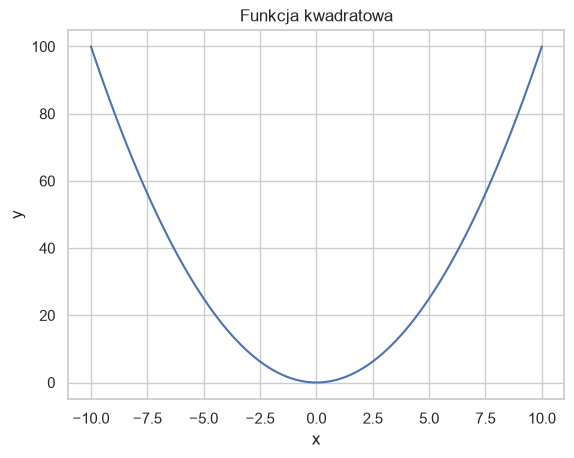

In [3]:
x = np.linspace(-10, 10, 100)
y = x**2

plt.plot(x, y)
plt.title("Funkcja kwadratowa")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)

### ✏️ Zadanie 2 — Histogram z KDE

Wygeneruj 1000 losowych liczb z rozkładu normalnego (mean=0, std=1)
i stwórz histogram z nałożoną krzywą KDE.

**Wymagania:**
- 30 bins, kolor 'steelblue', przezroczystość 0.7
- Dodaj linię pionową dla średniej (czerwona, przerywana)

*(proste)*

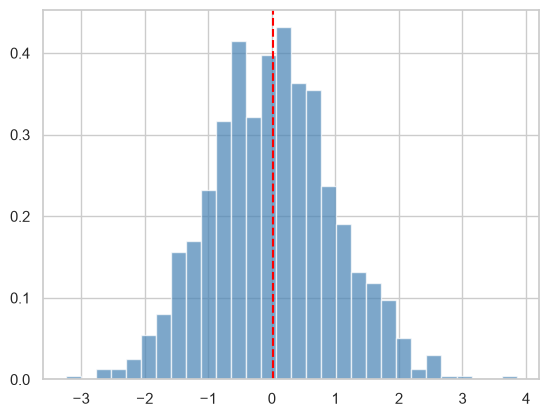

In [4]:
norm_num = np.random.normal(0, 1, 1000)

plt.hist(norm_num, color='steelblue', bins=30, alpha=0.7, density=True)
plt.axvline(np.mean(norm_num), color='red', linestyle='--')
plt.show()


### ✏️ Zadanie 3 — Wykres słupkowy

Stwórz wykres słupkowy pokazujący **średnią cenę biletu** na Titanicu według klasy pasażerskiej.

**Wymagania:**
- Użyj `groupby` i `mean`
- Dodaj wartości na słupkach
- Różne kolory dla klas

*(proste)*

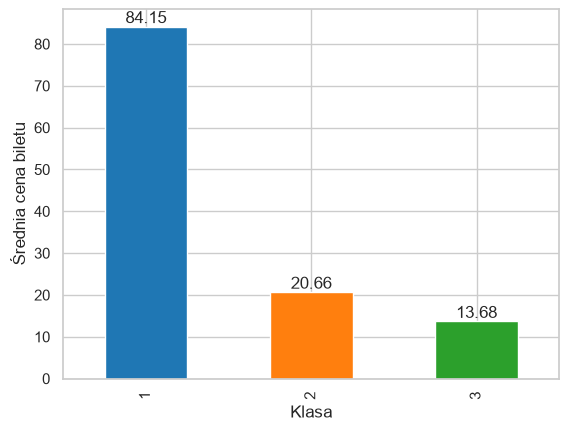

In [5]:
titanic_ticket_price = titanic.groupby("pclass")["fare"].mean()

ax = titanic_ticket_price.plot(
    kind="bar",
    color=["#1f77b4", "#ff7f0e", "#2ca02c"]
)

for i, value in enumerate(titanic_ticket_price):
    ax.text(i, value, f"{value:.2f}", ha="center", va="bottom")

plt.xlabel("Klasa")
plt.ylabel("Średnia cena biletu")

plt.show()

### ✏️ Zadanie 4 — Scatter plot

Na datasecie Iris stwórz scatter plot: **sepal_length vs petal_length**
z kolorowaniem według gatunku.

**Wymagania:**
- Różne kolory dla każdego gatunku
- Legenda, przezroczystość 0.6

*(proste)*

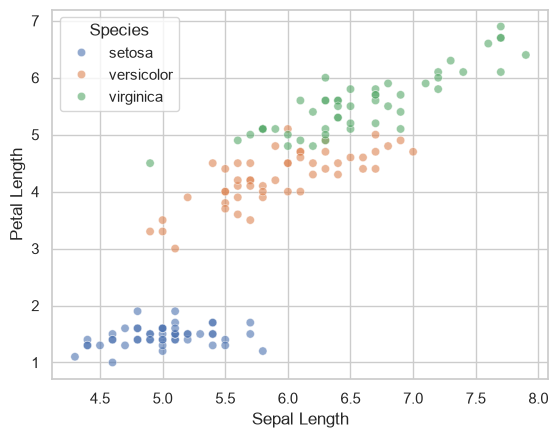

In [6]:
iris_scatter = sns.scatterplot(
    data=iris,
    x="sepal_length",
    y="petal_length",
    hue="species",
    alpha=0.6
)

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.legend(title="Species")
plt.show()

### ✏️ Zadanie 5 — Box plot porównawczy

Stwórz box plot porównujący **wiek pasażerów Titanica** według klasy i płci.

**Wymagania:**
- Klasa na osi X, Wiek na osi Y, podział na płeć (hue)

*(proste)*

KeyError: ''

### ✏️ Zadanie 6 — Pie chart

Stwórz wykres kołowy pokazujący **proporcje gatunków** w datasecie Iris.

**Wymagania:**
- Użyj `value_counts()`, dodaj procenty, eksploduj największy kawałek

*(proste)*

### ✏️ Zadanie 7 — Subplots 2×2

Stwórz siatkę 2×2 wykresów dla datasetu Tips:
- Histogram `total_bill`
- Histogram `tip`
- Scatter: `total_bill` vs `tip`
- Box plot: `tip` według dnia

*(proste)*

### ✏️ Zadanie 8 — Heatmap korelacji

Stwórz heatmap korelacji dla zmiennych numerycznych datasetu Tips.

**Wymagania:**
- Annotacje (2 miejsca po przecinku), paleta `'coolwarm'`, kwadratowe komórki

*(proste)*

<Axes: >

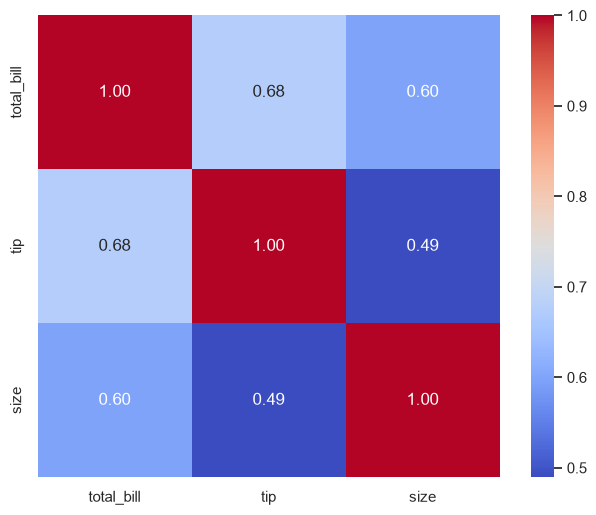

In [8]:
tips_corr = tips.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    tips_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

---
## ✏️ Zadania średnie (9–12)

### ✏️ Zadanie 9 — Dashboard EDA (Penguins)

Stwórz kompletny dashboard EDA dla datasetu Penguins z 4 wykresami:
- Rozkład masy ciała (histogram z KDE)
- Scatter: `bill_length` vs `bill_depth` wg gatunku
- Box plot: `flipper_length` według gatunku
- Bar plot: liczebność według gatunku i płci

*(średnie)*

### ✏️ Zadanie 10 — Wykres czasowy (cena akcji)

Utwórz wykres ceny akcji w czasie z:
- Główną linią ceny
- Średnią kroczącą 7-dniową (MA7)
- Średnią kroczącą 21-dniową (MA21)
- Zacienionym obszarem między MA7 a MA21

```python
np.random.seed(42)
dates = pd.date_range('2025-01-01', periods=100)
price = 100 + np.cumsum(np.random.randn(100))
df = pd.DataFrame({'date': dates, 'price': price})
```

*(średnie)*

---
## 🧠 Zadania wyzwanie i pozostałe średnie (11–20)

### ✏️ Zadanie 11 — Interaktywny scatter Plotly (Gapminder)

Stwórz interaktywny scatter plot Gapminder (rok 2007):
- GDP per capita (log scale) na osi X, Life expectancy na osi Y
- Rozmiar punktów = populacja, Kolor = kontynent, Tooltip = kraj

*(średnie)*

### ✏️ Zadanie 12 — FacetGrid

Stwórz FacetGrid pokazujący rozkład napiwków (`tip`) w podziale na:
- Kolumny: `time` (lunch/dinner), Wiersze: `smoker` (yes/no)
- Typ wykresu: histogram z KDE

*(średnie)*

### 🧠 Zadanie 13 — Analiza geograficzna (pseudo-mapa Kalifornii)

Używając California Housing dataset, stwórz "pseudo-mapę" Kalifornii:
- Scatter plot: Longitude vs Latitude
- Kolor punktów = cena domu (MedHouseVal)
- Rozmiar punktów = populacja (Population)
- Anotacje dla regionów o najwyższych cenach

*(challenge)*

> *Uwaga: używamy syntetycznych danych z parametrami Kalifornii.*

### 🧠 Zadanie 14 — Animowany wykres Plotly

Stwórz animowany wykres Plotly: ewolucja GDP per capita i life expectancy
w czasie (1952-2007) dla 10 wybranych krajów.

*(challenge)*

### 🧠 Zadanie 15 — Dashboard finansowy (Plotly)

Stwórz interaktywny dashboard Plotly z 4 wykresami (`make_subplots`):
- Wykres świecowy (candlestick) ceny
- Wykres wolumenu (bar chart)
- RSI indicator (14-dniowy)
- Histogram dziennych stóp zwrotu

*(challenge)*

### 🧠 Zadanie 16 — Confusion Matrix multi-class (Digits)

Przeprowadź klasyfikację wieloklasową na datasecie Digits (cyfry 0-9) i stwórz:
- Confusion matrix 10×10 jako heatmap
- Normalizowaną confusion matrix (% per klasa)
- Bar plot z F1-score dla każdej cyfry
- Przykłady źle sklasyfikowanych cyfr

*(challenge)*

### 🧠 Zadanie 17 — Pair plot zaawansowany (Wine Quality)

Stwórz zaawansowany pair plot dla Wine Quality dataset:
- Tylko 5 najważniejszych cech (wg korelacji z quality)
- Diagonala: KDE, kolorowanie wg kategorii jakości (low/medium/high)

*(challenge)*

### 🧠 Zadanie 18 — Interaktywny Sunburst (Gapminder)

Stwórz hierarchiczny wykres sunburst dla Gapminder 2007:
- Poziom 1: Kontynent, Poziom 2: Kraj
- Wartość: Populacja, Kolor: Life expectancy

*(challenge)*

### 🧠 Zadanie 19 — Porównanie modeli ML (Breast Cancer)

Porównaj 5 algorytmów ML na datasecie Breast Cancer:
- Bar plot: Accuracy, Box plot: CV scores, Radar chart: metryki

*(challenge)*

### 🧠 Zadanie 20 — Interaktywny dashboard Titanic

Stwórz kompletny interaktywny dashboard Plotly z dropdown do wyboru cechy,
statystykami KPI i eksportem do HTML.

*(challenge)*